### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.

```
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()
```

**1.**\
Here `pandas` is for reading tabular data, `geopandas` is for reading tabular data prepared for geographic informations,`geodatasets` provides ready-made geographic datasets (it is useful for world map), `matplotlib` is used for plotting figures. \
We start with creating dataframe taken from Nam2.txt and assign it as `df`. Then, we extract relevant columns as `latitude`, `logtitude`, `tribes`. After that we convert our usual dataset into geographical one and assign it as gdf, and we basically start to have just points with `latitude`and `logtitude`, so each individual is presented as point . Also we take world maps from naturaleart.land. After that we cretae figures and adjust margins. Then from world land map we clip map to North America, by adding 4 boundaries, and put colors to different shapes. In the end, we do loop to determine all `tribes` and plot `tribes` locations

In [2]:
!pip install geodatasets

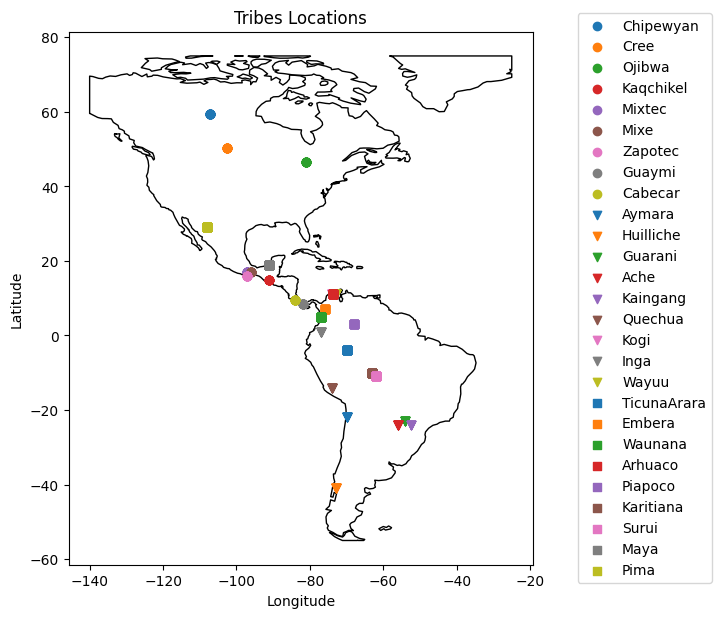

In [3]:
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt

# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))
# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe['long'], members_tribe['lat'],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

In [4]:
X = df.iloc[:, 8:].values
y = df.iloc[:, 7].values

In [5]:
print(X.shape)

(494, 5709)


## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$.

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [6]:
df.head()

,IndivID,PopID,Pop,Country,Continent,sex,lat,long,L1.125,L1.130,...,L677.255.553287981859,L677.259,L677.263,L677.267,L678.202,L678.206,L678.209.848101265823,L678.210,L678.214,L678.218
Chipewyan29,2012,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,0,1,0,0
Chipewyan31,2156,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,1,0,0,0
Chipewyan33,2381,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,1,0,0,0,0
Chipewyan35,2382,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,0,1,0,0
Chipewyan37,2383,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,1,0,0,0,0,0,1,0,0


In [7]:
df.columns

Index(['IndivID', 'PopID', 'Pop', 'Country', 'Continent', 'sex', 'lat', 'long',
       'L1.125', 'L1.130',
       ...
       'L677.255.553287981859', 'L677.259', 'L677.263', 'L677.267', 'L678.202',
       'L678.206', 'L678.209.848101265823', 'L678.210', 'L678.214',
       'L678.218'],
      dtype='object', length=5717)

In [8]:
#a)
import numpy as np
X=df.iloc[:,8:].values#column 9
y=df.iloc[:,7].values#column 8
#we want to compute the beta hat
beta_hat=np.linalg.solve(X.T@X,X.T@y)

LinAlgError: Singular matrix

In [9]:
r=np.linalg.matrix_rank(X)
print(r)
X.shape
#comparing rank with p

494


(494, 5709)

**2.a** \
Here we see that the system we are trying to solve is underdetermined where the rank is not strictly less than p. This causes problems related to the invertibility of the matrix and thus makes solving this system using linalg.solve impossible.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result).

And now? Did you get any errors? Why is that?

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

**2.b** \
numpy.linalg.solve solves a system of linear equations $Ax=b$.
By assuming A is a squared and invertible matrix,
and it computes the exact solution of A by doing an LU decomposition ,giving an error if A is not invertible.\

Meanwhile, numpy.linalg.lstsq solves the least squares problem $||b-Ax||²$, so it doesn't have to calculate (X^TX)^-1 and does not assume invertibility, it uses SVD (singular value decomposition), so it can compute the least-squares solution even when the classical formula fails.

in our context the data matrix $X \in R^{N*p}$  then $\text{rank}(X) < p$,the lstsq can handle the matrix singularity



In [10]:
beta, residuals, rank, s=np.linalg.lstsq(X, y, rcond=None)
print("rank of X:", rank)
print("number of coefficients:", len(beta))

rank of X: 494
number of coefficients: 5709


 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

```
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)
```

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model.

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = LinearRegression()
lr.fit(X, y)

LinearRegression()

In [13]:
lr.coef_

array([-0.03940988, -0.0245272 ,  0.01089763, ...,  0.04804479,
       -0.08985062,  0.01903025])

In [14]:
beta[:10]
lr.coef_[:10]

array([-0.03940988, -0.0245272 ,  0.01089763,  0.01066482, -0.02470103,
       -0.13710644,  0.13253656,  0.22427817,  0.00846413, -0.09187887])

**2.c** \
The coefficients obtained with `sklearn` may differ slightly from those obtained with `numpy.linalg.lstsq`. This is because `sklearn` automatically centers the predictors before fitting the regression model. Centering substracts the mean of each predictor, which changes the value of the intercept, but not the fitted predictions itself. A practical reason for this re-centering is that the intercept then represents the expected value of the response when the predictors take their average values,rather than when they are actually at zero, making it easier to interpret.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

**3.a** \
PCA is a dimensionality reduction technique that transforms a set of possibly correlated variables into a new set of orthogonal variables. \
From a statistical perspective, Pca identifies directions in the data that maximize variance. So the first principal component is the direction with maximum variance, and the second captures thr largest remaining variance while being orthogonal to the first one, and so on...\
From a geometric perspective, PCA can be explained as a rotation of the coordinate system so that the new axes align with the directions of greatest spread of the data. And projecting the data onto the first few prinicpal components provides a lower-dimensional representation that preserves most of the information in the data

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

In [15]:
#3.b
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [16]:
X = df.iloc[:, 8:].values
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X)

In [17]:
X_pca.shape

(494, 2)

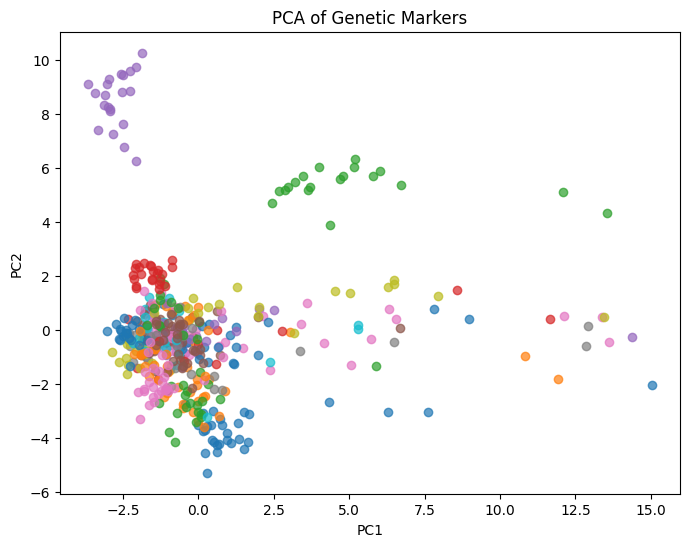

In [18]:
#we need the tribe names to color the points
tribes=df['Pop']
plt.figure(figsize=(8,6))
for tribe in tribes.unique():
    idx=tribes==tribe
    plt.scatter(X_pca[idx,0],X_pca[idx,1],label=tribe,alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Genetic Markers")
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

In [19]:
#3.c
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)

In [20]:
X_pca=pca.fit_transform(X_std)

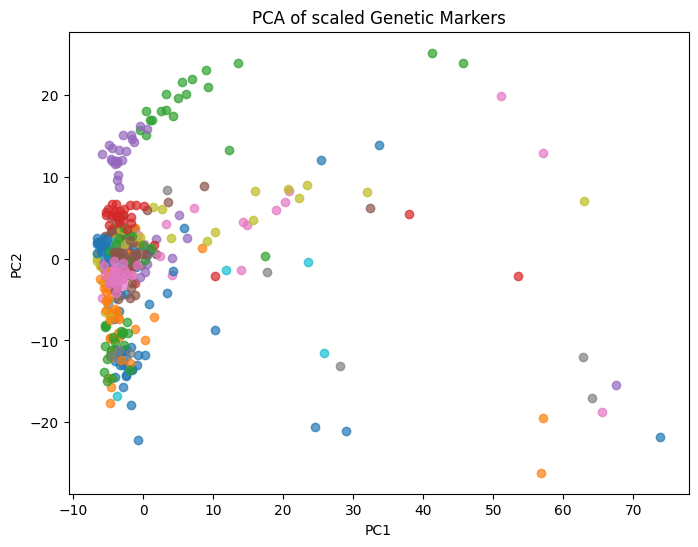

In [21]:
#we need the tribe names to color the points
tribes=df['Pop']
plt.figure(figsize=(8,6))
for tribe in tribes.unique():
    idx=tribes==tribe
    plt.scatter(X_pca[idx,0],X_pca[idx,1],label=tribe,alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of scaled Genetic Markers")
plt.show()

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

**3.d** \
After normalizing the predictors, we recomputed the PCA and plotted the first two principal components. The resulting plot differs from the previous one because standartization removes  overlapping especially near the origin, and creates clearer clustering of data points belonging to the same tribe together. Without scaling, PCA is dominated by variables with larger variance. After normalization, each marker contributes equally to the computation of the principal components, which changes the orientation and spread of the data in the PCA projection to more accurately reflect the contribution of the components to the variance in the data.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

In [22]:
pca.explained_variance_ratio_


array([0.02367493, 0.01025105])

In [23]:
pca.explained_variance_ratio_.sum()

np.float64(0.03392597703134863)

**3.e** \
Here we see that first principal component contributes 2.3% and the second principal component contributes 1%, so together they capture 3% of the total variance

**3.e**\
According to the cumulative explained variance plot and numerical results, about 299, 376, and 425 components are needed to explain 80%, 90%, and 95% of the variance, respectively.

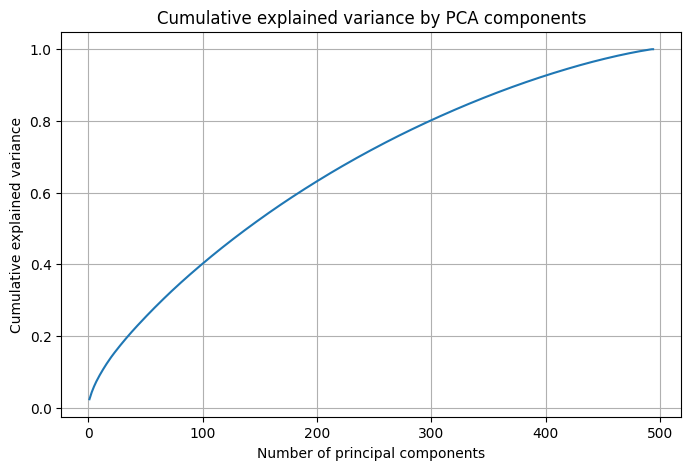

In [24]:
pca_full=PCA()
X_pca_full=pca_full.fit_transform(X_std)
pca_full.explained_variance_ratio_
cum_var=np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var)
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative explained variance by PCA components")
plt.grid(True)
plt.show()

In [25]:
k80=np.argmax(cum_var>=0.80)+1
k90=np.argmax(cum_var>=0.90)+1
k95=np.argmax(cum_var>=0.95)+1
print("number of PCs for 80% variance:", k80)
print("number of PCs for 90% variance:", k90)
print("number of PCs for 95% variance:", k95)

k70=np.argmax(cum_var>=0.7)+1
print("number of PCs for 70% variance:", k70)

number of PCs for 80% variance: 299
number of PCs for 90% variance: 376
number of PCs for 95% variance: 425
number of PCs for 70% variance: 237


## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

In [26]:
#4.a
pca_250=PCA(n_components=250)
X_pca_250=pca_250.fit_transform(X_std)
X_pca_250.shape

(494, 250)

In [34]:
gdf.head()

,IndivID,PopID,Pop,Country,Continent,sex,lat,long,L1.125,L1.130,...,L677.259,L677.263,L677.267,L678.202,L678.206,L678.209.848101265823,L678.210,L678.214,L678.218,geometry
Chipewyan29,2012,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,1,0,0,POINT (-106.4413 55.2728)
Chipewyan31,2156,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,1,0,0,0,POINT (-109.88993 58.09091)
Chipewyan33,2381,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,1,0,0,0,0,POINT (-104.59226 54.44095)
Chipewyan35,2382,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,1,0,0,POINT (-104.60595 50.51711)
Chipewyan37,2383,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,1,0,0,0,0,0,1,0,0,POINT (-108.80967 58.91868)


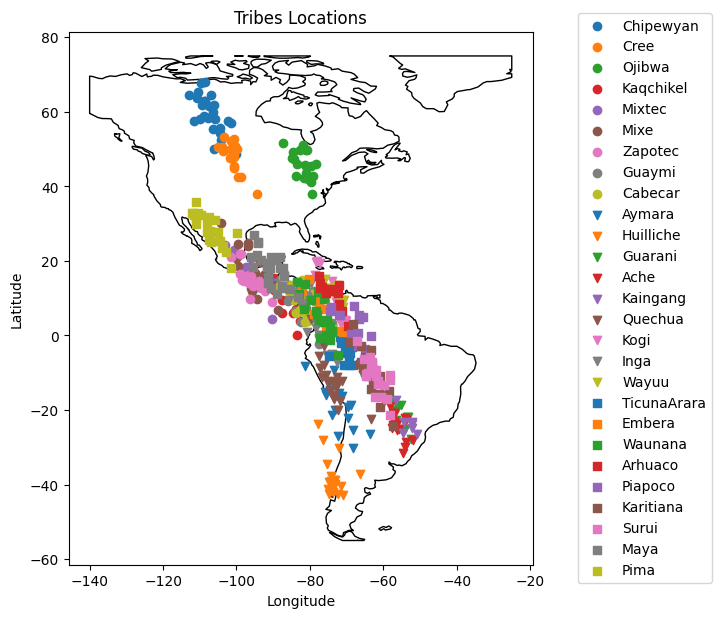

In [35]:
y_lat=df['lat'].values
y_long=df['long'].values
lr_lat=LinearRegression()
lr_long=LinearRegression()
lr_lat.fit(X_pca_250, y_lat)
lr_long.fit(X_pca_250, y_long)
lat_pred=lr_lat.predict(X_pca_250)
long_pred=lr_long.predict(X_pca_250)
# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(long_pred, lat_pred))
# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe]
    ax.scatter(members_tribe.geometry.x, members_tribe.geometry.y,  marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)  # ← predicted coords
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()


**4.a** \
The predicted map roughly resembles the true geographic distribution of the tribes, which shows that genetic markers contain information about geographical origin.
The predicted map highly resembles a somewhat distorted/noisy version of the true map.
However, this result is somewhat optimistic because the model is evaluated on the same dataset used to train it. Therefore the predicted map reflects the training performance rather than the true predictive ability for new individuals outside the dataset.
In addition, as we will see later on, this number of components causes the model to overfit the training data, giving deceptively high accuracy.

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [28]:
print(y_lat[:5], y_long[:5])
print(lat_pred[:5], long_pred[:5])

[59.55 59.55 59.55 59.55 59.55] [-107.3 -107.3 -107.3 -107.3 -107.3]
[55.27279987 58.09090672 54.4409514  50.51711188 58.91868066] [-106.44129921 -109.88993142 -104.59225536 -104.6059529  -108.80966812]


In [29]:
#4.b
import numpy as np
from sklearn.metrics.pairwise import haversine_distances
real_coord=np.vstack((y_lat,y_long)).T
pred_coord=np.vstack((lat_pred,long_pred)).T
real_rad=np.radians(real_coord) #we convert degrees to radianc bcs haversine formula works in rad
pred_rad=np.radians(pred_coord)
dist_matrix=haversine_distances(real_rad,pred_rad)
dist_km=np.diag(dist_matrix)*6371
mean_error=np.mean(dist_km)
print("Mean prediction error(in km):", mean_error)


Mean prediction error(in km): 508.3261128772549


**4.b** \
It means that, on average, the location of an individual is correctly estimated within a 500km circle.

## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates.

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

**5.a** \
Cross-validation consists in splitting the dataset into several folds, training the model on some folds and testing on remaining ones, then repeating the process and averaging the errors. It is useful because it provides a better estimate of prediction performance on unseen data.
When samples are not i.i.d., standard random splitting can lead to overly optimistic results because related samples may appear in both train and test sets. .\
Several strategies address this: TimeSeriesSplit for temporal data, where the model is always trained on past observations and tested on future ones; GroupKFold or LeaveOneGroupOut for clustered data (e.g. multiple samples per patient or tribe), where entire groups are held out to test generalization to unseen groups; and StratifiedKFold for classification tasks with imbalanced classes, which ensures each fold preserves the original class proportions

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

**5.b**\
In this laboratory work, we are using two approaches in cross-validation: classical KFold and GroupKFold. Afterwards, we will conclude the results.

---


*Motivation for KFold* \
Before considering the specific characteristics of the dataset, K-fold cross-validation seemed the most suitable.\
In this method, the dataset is split into k subsets , where each fold is used once on the test set and while the remaining are used for training .\
This approach provides more stable results that the single hold-out and also less computationally expensive than leave-one-out cross-validation .


---

*Motivation for GroupKFold*
However, given that the dataset at hand contains groups (tribes), creating a risk for data leakage when using cross-validation if their presence is ignored, group k-fold was chosen.
More specifically, individuals from the same population are genetically very similar; so it means that observations are not IID. If we randomly split individuals into folds, the training and test sets may contain very similar individuals from the same populations. So we should choose GroupKFold, because it will allow us to group observations by population or by country, and ensure that all individuals from the same group stay in the same fold.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [30]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
X=df.iloc[:, 8:].values
Y=df[['lat', 'long']].values
groups=df['Pop'].values
gkf=GroupKFold(n_splits=10)
pcr_model=make_pipeline(
    StandardScaler(), PCA(n_components=4),LinearRegression()
)
fold_errors=[]
earth_R=6371
for train_idx, test_idx in gkf.split(X,Y,groups=groups):
    X_train, X_test=X[train_idx], X[test_idx]
    Y_train, Y_test=Y[train_idx], Y[test_idx]
    pcr_model.fit(X_train, Y_train)
    Y_pred=pcr_model.predict(X_test)

    Y_test_rad=np.radians(Y_test)
    Y_pred_rad=np.radians(Y_pred)
    dist_rad=np.diag(haversine_distances(Y_test_rad, Y_pred_rad))
    dist_km=dist_rad*6371
    fold_errors.append(dist_km.mean())
print("Fold errors (km):", fold_errors)
print("Mean CV error (km):", np.mean(fold_errors))
print("Std CV error (km):", np.std(fold_errors))

Fold errors (km): [np.float64(3631.113704052063), np.float64(1826.0019099474587), np.float64(2580.09641268614), np.float64(1757.236753293413), np.float64(2649.8854051560143), np.float64(1124.2079793147934), np.float64(2327.050576121755), np.float64(4479.136440036419), np.float64(2172.692863416759), np.float64(2309.4196286003316)]
Mean CV error (km): 2485.6841672625146
Std CV error (km): 910.7890860228478


In [31]:
!pip install geopandas geodatasets

**5.c** \
We evaluated the PCR model with n_components=4 using a scikit-learn pipeline combining standartization, PCA, and linear regression. Using a pipeline avoids data leakage, since the scalar and PCA are fitted only on the training folds. We used GroupKFold with population labels as groups to ensure that indiviuals from the same population are not split between train and test sets. The prediction error was measured in km using the haversine distance between true and predicted coordinates

**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

In [45]:
!pip install kneed

In [47]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X = df.iloc[:, 8:].values
Y = df[['lat', 'long']].values
groups = df['Pop'].values
gkf = GroupKFold(n_splits=10)
n_components_list = np.arange(2, 441, 10)

train_errors_mean = []
test_errors_mean = []
test_errors_std = []

for n_comp in n_components_list:
    fold_train_errors = []
    fold_test_errors = []

    pcr_model = make_pipeline(
        StandardScaler(), PCA(n_components=n_comp), LinearRegression()
    )

    for train_idx, test_idx in gkf.split(X, Y, groups=groups):
        X_train, X_test = X[train_idx], X[test_idx]
        Y_train, Y_test = Y[train_idx], Y[test_idx]
        pcr_model.fit(X_train, Y_train)

        Y_train_pred = pcr_model.predict(X_train)
        Y_test_pred = pcr_model.predict(X_test)

        Y_train_rad = np.radians(Y_train)
        Y_train_pred_rad = np.radians(Y_train_pred)
        Y_test_rad = np.radians(Y_test)
        Y_test_pred_rad = np.radians(Y_test_pred)

        train_dist_km = np.diag(haversine_distances(Y_train_rad, Y_train_pred_rad)) * 6371
        test_dist_km = np.diag(haversine_distances(Y_test_rad, Y_test_pred_rad)) * 6371

        fold_train_errors.append(train_dist_km.mean())
        fold_test_errors.append(test_dist_km.mean())

    train_errors_mean.append(np.mean(fold_train_errors))
    test_errors_mean.append(np.mean(fold_test_errors))
    test_errors_std.append(np.std(fold_test_errors))  # <- new



Method                  N components    Test error (km)
-------------------------------------------------------
argmin                           432            2133.58
1-SE rule                          2            2543.74
5% of minimum                     72            2197.77
Knee                              42            2246.10


In [ ]:
# KFold version - demonstration only, not used for final model selection
import pandas as pd
import numpy as np
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import haversine_distances
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Load the data
_file_path = 'NAm2.txt'
_df_kfold = pd.read_csv(_file_path, delimiter=' ')

# Extract relevant columns
_latitude_kfold = _df_kfold.iloc[:, 6]
_longitude_kfold = _df_kfold.iloc[:, 7]
_X_kfold = _df_kfold.iloc[:, 8:]
_y_kfold = np.column_stack((_latitude_kfold, _longitude_kfold))

# pipeline
_model_kfold = make_pipeline(StandardScaler(), PCA(n_components=4), LinearRegression())
_kf = KFold(n_splits=5, shuffle=True, random_state=42)
_errors_kfold = []

for _train_i, _test_i in _kf.split(_X_kfold):
    _X_train_kf, _X_test_kf = _X_kfold.iloc[_train_i], _X_kfold.iloc[_test_i]
    _y_train_kf, _y_test_kf = _y_kfold[_train_i], _y_kfold[_test_i]
    _model_kfold.fit(_X_train_kf, _y_train_kf)
    _prediction_kf = _model_kfold.predict(_X_test_kf)
    _y_test_r_kf = np.radians(_y_test_kf)
    _pred_kf = np.radians(_prediction_kf)
    _distances_kf = haversine_distances(_y_test_r_kf, _pred_kf)
    _distances_km_kf = np.diag(_distances_kf) * 6371
    _errors_kfold.append(np.mean(_distances_km_kf))

print("KFold - Fold errors (km):", _errors_kfold)
print("KFold - Mean CV error (km):", np.mean(_errors_kfold))
print("KFold - Std CV error (km):", np.std(_errors_kfold))



*Conclusion for cross-validation iterators* \
We compared the results obtained using KFold and GroupKFold cross-validation. The KFold procedure produced a much smaller mean prediction error and a very small standard deviation (around 51 km), while GroupKFold produced a larger mean error and a much larger standard deviation (around 913 km). According to the numerical criterion of mean prediction error, the KFold model appears to perform better. However, the difference can be explained by the structure of the data: individuals from the same population share similar genetic markers. With KFold, individuals from the same population may appear in both training and test folds, which makes the prediction task easier. In contrast, GroupKFold keeps populations separated across folds, forcing the model to predict the location of populations not seen during training, which results in larger and more variable errors.

In [48]:
train_errors_mean = np.array(train_errors_mean)
test_errors_mean = np.array(test_errors_mean)
test_errors_std = np.array(test_errors_std)

# --- argmin ---
best_idx = np.argmin(test_errors_mean)
best_n_comp = n_components_list[best_idx]
best_test_error = test_errors_mean[best_idx]
best_train_error = train_errors_mean[best_idx]

# --- 1-SE rule ---
threshold_1se = best_test_error + test_errors_std[best_idx]
best_idx_1se = np.where(test_errors_mean <= threshold_1se)[0][0]
best_n_comp_1se = n_components_list[best_idx_1se]
best_test_error_1se = test_errors_mean[best_idx_1se]
best_train_error_1se = train_errors_mean[best_idx_1se]

# --- 5% of minimum ---
threshold_5pct = best_test_error * 1.05
best_idx_5pct = np.where(test_errors_mean <= threshold_5pct)[0][0]
best_n_comp_5pct = n_components_list[best_idx_5pct]
best_test_error_5pct = test_errors_mean[best_idx_5pct]
best_train_error_5pct = train_errors_mean[best_idx_5pct]

# --- knee ---
from kneed import KneeLocator
knee = KneeLocator(n_components_list, test_errors_mean, curve='convex', direction='decreasing')
best_n_comp_knee = knee.knee
knee_idx = np.where(n_components_list == best_n_comp_knee)[0][0]
best_test_error_knee = test_errors_mean[knee_idx]
best_train_error_knee = train_errors_mean[knee_idx]

# --- summary ---
print(f"{'Method':<20} {'N components':>15} {'Train error (km)':>18} {'Test error (km)':>18}")
print("-" * 75)
print(f"{'argmin':<20} {best_n_comp:>15} {best_train_error:>18.2f} {best_test_error:>18.2f}")
print(f"{'1-SE rule':<20} {best_n_comp_1se:>15} {best_train_error_1se:>18.2f} {best_test_error_1se:>18.2f}")
print(f"{'5% of minimum':<20} {best_n_comp_5pct:>15} {best_train_error_5pct:>18.2f} {best_test_error_5pct:>18.2f}")
print(f"{'Knee':<20} {best_n_comp_knee:>15} {best_train_error_knee:>18.2f} {best_test_error_knee:>18.2f}")

Method                  N components   Train error (km)    Test error (km)
---------------------------------------------------------------------------
argmin                           432              40.32            2133.58
1-SE rule                          2            2041.38            2543.74
5% of minimum                     72             866.02            2197.77
Knee                              42             957.32            2246.10


**5.d** \
We repeated the PCR cross-validation procedure for several values of `n_components` between 2 and 440. For each value, we computed the mean training and test errors across the folds using the haversine distance in km. As expected, the training error tends to decrease as the number of principal components increases. The test error first decreases, then reaches a minimum, and stabilizes afterwards. We experimented with several methods of choosing the right number of components to use for the model.

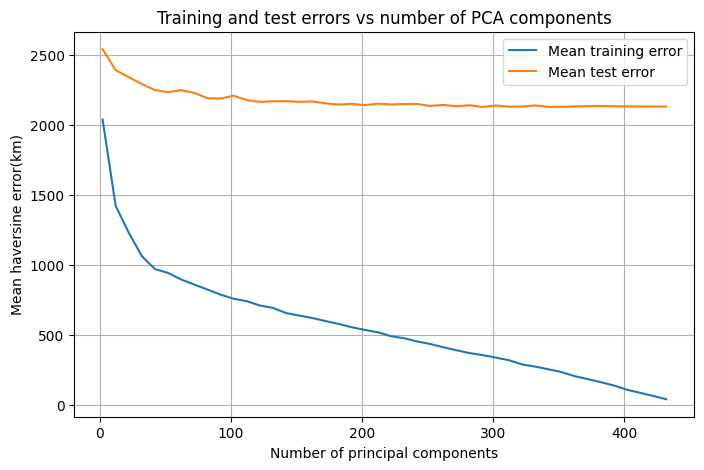

In [38]:
plt.figure(figsize=(8,5))
plt.plot(n_components_list, train_errors_mean, label="Mean training error")
plt.plot(n_components_list, test_errors_mean, label="Mean test error")
plt.xlabel("Number of principal components")
plt.ylabel("Mean haversine error(km)")
plt.title("Training and test errors vs number of PCA components")
plt.legend()
plt.grid(True)
plt.show()

**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

**5.e**

Different methods of selection lead to radically different 'right' number of components. We considered several approaches: the argmin method, which simply picks the number of components minimising test error; the 1-SE rule, which selects the simplest model within one standard deviation of the minimum; the 5% rule, which finds the simplest model whose error is within 5% of the minimum; and the knee method, which detects the point of sharpest curvature in the error curve.

We initially relied on a visual guide to choose the right number of components that have a reasonably low test error (measured using group k-fold) while still avoiding major overfitting. In our case, the 'elbow' appears in the figure around 50 components, after which the test error plateaus and no meaningful improvement is observed. This result was confirmed numerically at 42 components by the knee method, which detected the sharpest decrease in test error.

In the end, we chose the model with 42 components, since it strikes the best balance between test accuracy and simplicity. The difference in test error between 42 and 72 components is only ~50 km, while 42 components also shows a smaller deviation between the test and training errors. Comparing that to the model with the highest number of components, which showed very extreme overfitting.

In [49]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X = df.iloc[:, 8:].values
Y = df[['lat', 'long']].values
groups = df['Pop'].values
gkf = GroupKFold(n_splits=10)

best_pcr = make_pipeline(StandardScaler(), PCA(n_components=42), LinearRegression())

fold_train_errors = []
fold_test_errors = []

for train_idx, test_idx in gkf.split(X, Y, groups=groups):
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]
    best_pcr.fit(X_train, Y_train)

    Y_test_pred = best_pcr.predict(X_test)
    Y_train_pred = best_pcr.predict(X_train)

    dist_km_test = np.diag(haversine_distances(np.radians(Y_test), np.radians(Y_test_pred))) * 6371
    dist_km_train = np.diag(haversine_distances(np.radians(Y_train), np.radians(Y_train_pred))) * 6371

    fold_test_errors.append(dist_km_test.mean())
    fold_train_errors.append(dist_km_train.mean())

print("Mean train error (km):", np.mean(fold_train_errors))
print("Mean test error (km):", np.mean(fold_test_errors))
print("Std test error (km):", np.std(fold_test_errors))

# final model fit on all data for map visualization
best_pcr.fit(X, Y)
Y_pred = best_pcr.predict(X)
lat_pred = Y_pred[:, 0]
long_pred = Y_pred[:, 1]

Mean train error (km): 957.544525537713
Mean test error (km): 2227.9524976609746
Std test error (km): 840.1241395458823


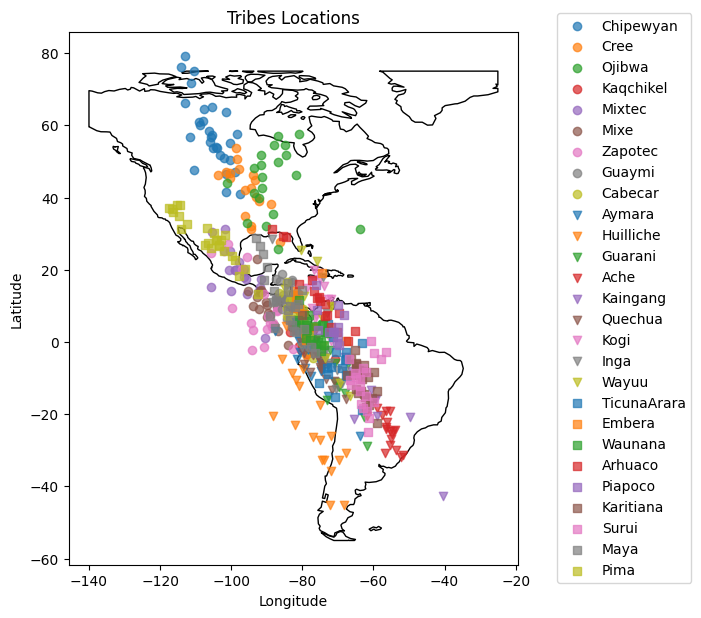

In [50]:
# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(long_pred, lat_pred))
# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members = gdf[gdf['Pop'] == tribe]
    ax.scatter(members.geometry.x, members.geometry.y,
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe, alpha=0.7)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()


## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

As noted above the prediction quality of the model improved significantly with each added predictor up until the mentioned threshold, where the additional predictors not adding a lot of predictive value.
This possibly means that many of the features in the dataset are related to each other, not capturing a lot of information about each individual.
This could also

PCR mean test error (km): 2266.26 ± 1494.78
PLS mean test error (km): 2146.31 ± 1419.08

Country-level comparison:
           PCR_error_km  PLS_error_km  difference_km better_model
Country                                                          
Chile       4778.340154   4419.064493    -359.275661          PLS
Peru        2121.915076   1764.515186    -357.399890          PLS
Paraguay    4010.749393   3767.193635    -243.555758          PLS
Mexico      2215.975762   2009.739547    -206.236215          PLS
Canada      3665.235396   3539.579802    -125.655594          PLS
Brazil      2643.810423   2532.419382    -111.391042          PLS
Colombia     973.469232    981.353861       7.884630          PCR
CostaRica    579.290280    596.077235      16.786955          PCR
Guatemala   1829.102793   1890.869524      61.766730          PCR
Panama       509.502034    614.220146     104.718111          PCR


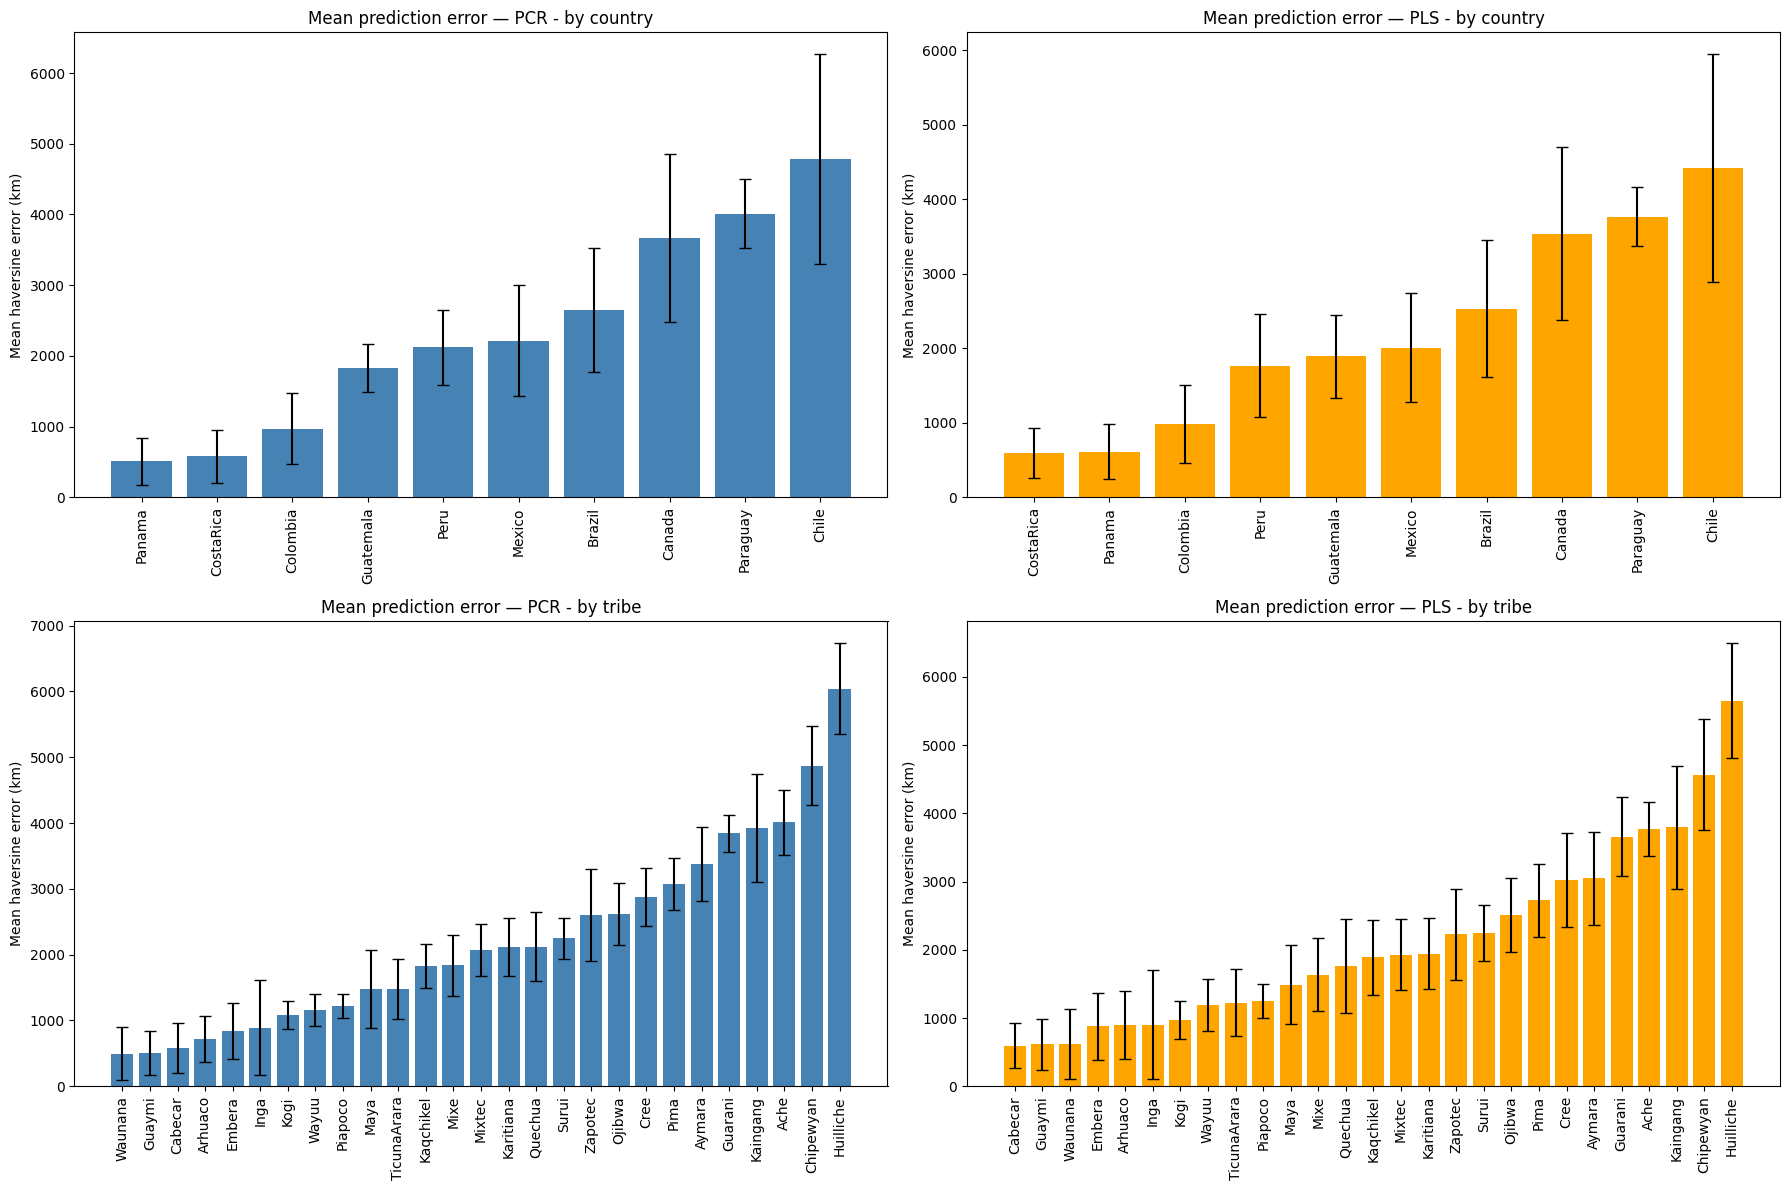

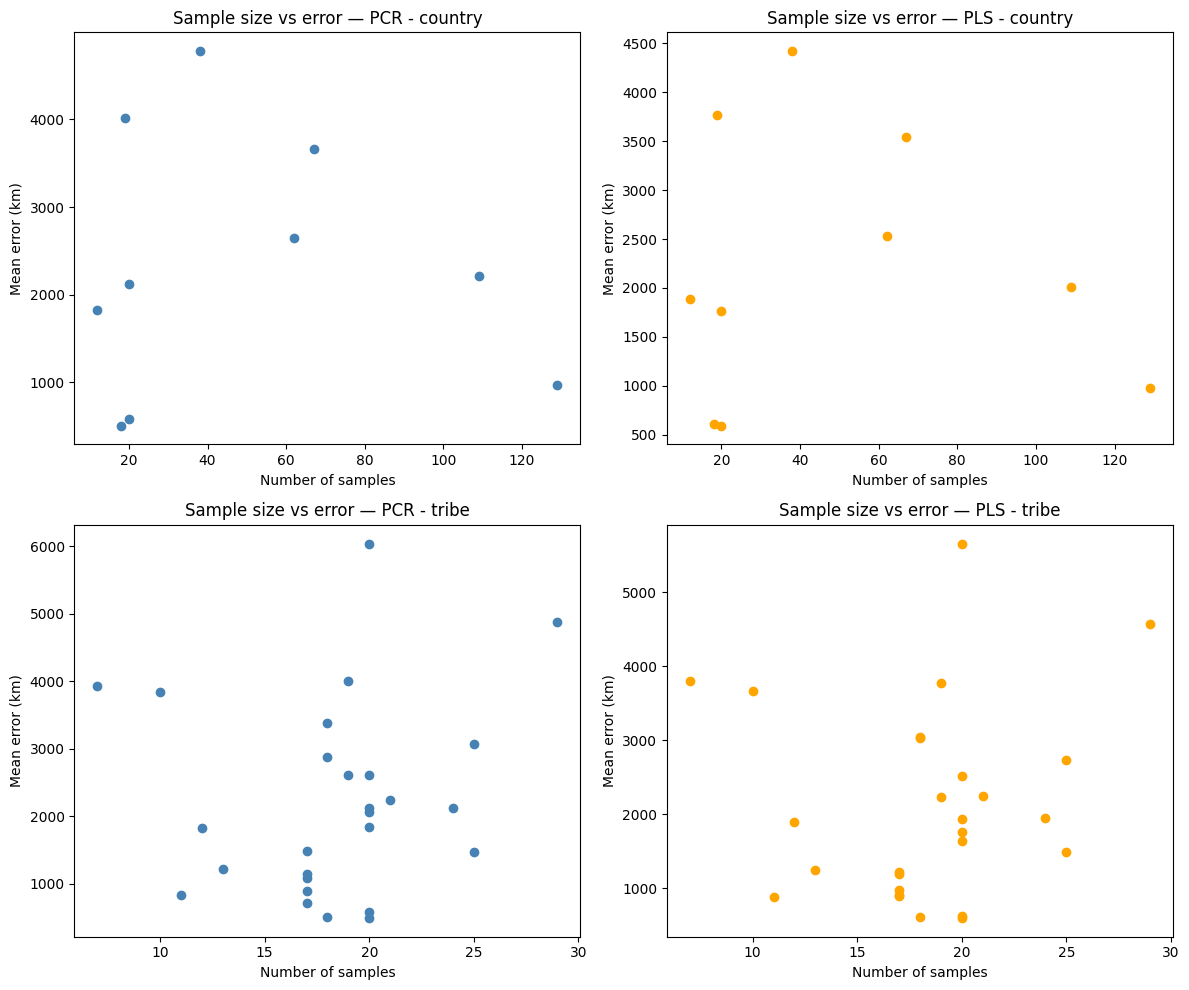

In [53]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict

X = df.iloc[:, 8:].values
Y = df[['lat', 'long']].values
groups = df['Pop'].values
gkf = GroupKFold(n_splits=10)

# --- cross-validated predictions ---
best_pcr = make_pipeline(StandardScaler(), PCA(n_components=42), LinearRegression())
best_pls = make_pipeline(StandardScaler(), PLSRegression(n_components=42))

Y_pred_pcr = cross_val_predict(best_pcr, X, Y, cv=gkf, groups=groups)
Y_pred_pls = cross_val_predict(best_pls, X, Y, cv=gkf, groups=groups)

# --- per-individual errors ---
coords_true = np.radians(df[['lat', 'long']].values)

errors_km_pcr = np.diag(haversine_distances(coords_true, np.radians(Y_pred_pcr))) * 6371
errors_km_pls = np.diag(haversine_distances(coords_true, np.radians(Y_pred_pls))) * 6371

df['error_km_pcr'] = errors_km_pcr
df['error_km_pls'] = errors_km_pls

print(f"PCR mean test error (km): {errors_km_pcr.mean():.2f} ± {errors_km_pcr.std():.2f}")
print(f"PLS mean test error (km): {errors_km_pls.mean():.2f} ± {errors_km_pls.std():.2f}")

# --- group errors ---
def group_errors(df, error_col, groupby_col):
    result = df.groupby(groupby_col)[error_col].agg(['mean', 'std', 'count'])
    result.columns = ['mean_error_km', 'std_error_km', 'n_samples']
    return result.sort_values('mean_error_km')

country_errors_pcr = group_errors(df, 'error_km_pcr', 'Country')
country_errors_pls = group_errors(df, 'error_km_pls', 'Country')
tribe_errors_pcr   = group_errors(df, 'error_km_pcr', 'Pop')
tribe_errors_pls   = group_errors(df, 'error_km_pls', 'Pop')

# --- comparison table ---
comparison_country = pd.DataFrame({
    'PCR_error_km': country_errors_pcr['mean_error_km'],
    'PLS_error_km': country_errors_pls['mean_error_km'],
})
comparison_country['difference_km'] = comparison_country['PLS_error_km'] - comparison_country['PCR_error_km']
comparison_country['better_model'] = np.where(comparison_country['difference_km'] < 0, 'PLS', 'PCR')
print("\nCountry-level comparison:")
print(comparison_country.sort_values('difference_km'))

# --- side by side bar plots ---
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
for ax, errors, title, color in zip(
    axes.flat,
    [country_errors_pcr, country_errors_pls, tribe_errors_pcr, tribe_errors_pls],
    ['PCR - by country', 'PLS - by country', 'PCR - by tribe', 'PLS - by tribe'],
    ['steelblue', 'orange', 'steelblue', 'orange']
):
    ax.bar(errors.index, errors['mean_error_km'], yerr=errors['std_error_km'],
           capsize=4, color=color)
    ax.set_title(f'Mean prediction error — {title}')
    ax.set_ylabel('Mean haversine error (km)')
    ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

# --- sample size vs error ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, errors, title, color in zip(
    axes.flat,
    [country_errors_pcr, country_errors_pls, tribe_errors_pcr, tribe_errors_pls],
    ['PCR - country', 'PLS - country', 'PCR - tribe', 'PLS - tribe'],
    ['steelblue', 'orange', 'steelblue', 'orange']
):
    ax.scatter(errors['n_samples'], errors['mean_error_km'], color=color)
    ax.set_xlabel('Number of samples')
    ax.set_ylabel('Mean error (km)')
    ax.set_title(f'Sample size vs error — {title}')
plt.tight_layout()
plt.show()

**PCR Model**

Based on the graphs presented above, there is little correlation between sample size and prediction error within each tribe or country, possibly due to the overall small sample sizes in the dataset.

A trend that can be observed at the country level is that geographic proximity to Central America correlates with lower average error. This suggests that genetic markers are more tightly linked to geographic location in these populations, possibly reflecting less historical dispersion compared to tribes in Canada or the Southern Cone.

**PLS Model**

The PLS model showed no clear relationship between sample size and error either. However, it achieved an overall lower cross-validated test error than PCR. This can be explained by a fundamental difference in how the two methods extract components: PCR finds directions of maximum variance in the genetic data without considering the geographic coordinates, while PLS finds directions of maximum covariance between genetics and geography, selecting components that are directly relevant to the prediction task. This makes PLS better suited to a setting where most genetic variation is within-population and therefore uninformative about location.